In [3]:
import requests as req 
from bs4 import BeautifulSoup as bs
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import time
import os
from urllib.request import urlretrieve

from scipy.stats import gaussian_kde


# https://velog.io/@sirasony12/%EC%A7%80%EB%8F%84-%EC%8B%9C%EA%B0%81%ED%99%94

# !pip install folium

import json

In [4]:
apart = pd.read_csv('data/Apart Deal.csv')
apart

C:\Users\heelo\AppData\Local\Temp\ipykernel_2604\2643238462.py:1: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  apart = pd.read_csv('data/Apart Deal.csv')


,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액
0,31110.0,학성동,5/30/2020 0:00,남운학성타운,379,135.5800,8,1991.0,26700
1,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2,2006.0,35500
2,31110.0,남외동,1/3/2020 0:00,에일린의뜰,500,84.9920,11,2007.0,36500
3,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8,2006.0,43000
4,31110.0,남외동,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7,2007.0,38700
...,...,...,...,...,...,...,...,...,...
5002834,50130.0,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6,2019.0,"19,500"
5002835,50130.0,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2,1999.0,"21,700"
5002836,50130.0,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1,2000.0,"9,300"
5002837,50130.0,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2,2003.0,"25,500"


# 아파트 데이터의 NaN 확인 및 정제- 김성재

In [3]:
apart.isna().sum()

지역코드      0
법정동       0
거래일       0
아파트       0
지번      438
전용면적      0
층         0
건축년도     76
거래금액      0
dtype: int64

In [4]:
nanUpdate = apart.copy()

## 건축년도 Nan 값 채우기 > 아파트와 법정동 기준으로 해당 아파트 찾은후, 추가

const_list = []
const_list.append(['조촌동', '더샵디오션시티', '2021'])
const_list.append(['무실동', '더샵원주센트럴파크1단지', '2021'])
const_list.append(['중앙동', '힐스테이트속초센트럴', '2021'])
const_list.append(['가평읍 읍내리', '가평코아루', '2021'])
const_list.append(['송도동', '더샵송도프라임뷰25BL', '2022'])
const_list.append(['오산동', '동탄역유림노르웨이숲', '2022'])
const_list.append(['양촌읍 양곡리', 'My더퍼스트', '2022'])
const_list.append(['신암동', 'SG펠리체', '2021'])


for i in const_list :
    temp = nanUpdate[(nanUpdate['법정동']==i[0]) & (nanUpdate['아파트']==i[1])].fillna(i[2]) 
    nanUpdate[(nanUpdate['법정동']==i[0]) & (nanUpdate['아파트']==i[1])] = temp

## 지번 NaN 값 채우기 > > 아파트와 법정동 기준으로 해당 아파트 찾은후, 추가

jibun_list = []
jibun_list.append(['남양읍 남양리', '동광뷰엘', '2235'])
jibun_list.append(['내곡동', '서초포레스타2단지', '384'])
jibun_list.append(['자곡동', '래미안포레', '687'])
jibun_list.append(['신원동', '힐스테이트 서초 젠트리스', '557'])
jibun_list.append(['나성동', '나릿재마을1단지', '259-1'])

for i in jibun_list :
    temp = nanUpdate[(nanUpdate['법정동']==i[0]) & (nanUpdate['아파트']==i[1])].fillna(i[2])
    nanUpdate[(nanUpdate['법정동']==i[0]) & (nanUpdate['아파트']==i[1])] = temp

    
nanUpdate

,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액
0,31110.0,학성동,5/30/2020 0:00,남운학성타운,379,135.5800,8,1991.0,26700
1,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2,2006.0,35500
2,31110.0,남외동,1/3/2020 0:00,에일린의뜰,500,84.9920,11,2007.0,36500
3,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8,2006.0,43000
4,31110.0,남외동,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7,2007.0,38700
...,...,...,...,...,...,...,...,...,...
5002834,50130.0,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6,2019.0,"19,500"
5002835,50130.0,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2,1999.0,"21,700"
5002836,50130.0,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1,2000.0,"9,300"
5002837,50130.0,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2,2003.0,"25,500"


In [5]:
nanUpdate.isna().sum()

지역코드    0
법정동     0
거래일     0
아파트     0
지번      0
전용면적    0
층       0
건축년도    0
거래금액    0
dtype: int64

# 

In [6]:
apart_rev0 = nanUpdate.copy()
apart_rev0

,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액
0,31110.0,학성동,5/30/2020 0:00,남운학성타운,379,135.5800,8,1991.0,26700
1,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2,2006.0,35500
2,31110.0,남외동,1/3/2020 0:00,에일린의뜰,500,84.9920,11,2007.0,36500
3,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8,2006.0,43000
4,31110.0,남외동,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7,2007.0,38700
...,...,...,...,...,...,...,...,...,...
5002834,50130.0,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6,2019.0,"19,500"
5002835,50130.0,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2,1999.0,"21,700"
5002836,50130.0,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1,2000.0,"9,300"
5002837,50130.0,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2,2003.0,"25,500"


# 거래일 컬럼을 년월일로 구분하여 컬럼 추가 - 박희재, 김주현

In [7]:
apart_rev0

,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액
0,31110.0,학성동,5/30/2020 0:00,남운학성타운,379,135.5800,8,1991.0,26700
1,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2,2006.0,35500
2,31110.0,남외동,1/3/2020 0:00,에일린의뜰,500,84.9920,11,2007.0,36500
3,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8,2006.0,43000
4,31110.0,남외동,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7,2007.0,38700
...,...,...,...,...,...,...,...,...,...
5002834,50130.0,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6,2019.0,"19,500"
5002835,50130.0,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2,1999.0,"21,700"
5002836,50130.0,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1,2000.0,"9,300"
5002837,50130.0,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2,2003.0,"25,500"


# 1046640번째 이전 년 월 일 컬럼 추가

In [8]:
date_1 = apart_rev0['거래일'].iloc[:1046640]
date_1

0          5/30/2020 0:00
1           1/3/2020 0:00
2           1/3/2020 0:00
3           1/3/2020 0:00
4           1/4/2020 0:00
                ...      
1046635     2/3/2018 0:00
1046636     2/5/2018 0:00
1046637     2/6/2018 0:00
1046638     2/9/2018 0:00
1046639    2/19/2018 0:00
Name: 거래일, Length: 1046640, dtype: object

In [9]:
date_2 = pd.DataFrame(date_1)
date_2

,거래일
0,5/30/2020 0:00
1,1/3/2020 0:00
2,1/3/2020 0:00
3,1/3/2020 0:00
4,1/4/2020 0:00
...,...
1046635,2/3/2018 0:00
1046636,2/5/2018 0:00
1046637,2/6/2018 0:00
1046638,2/9/2018 0:00


In [10]:
month_list = []
day_list = []
year_list = []

for i in range(len(date_2['거래일'])):
    month, day, year = date_2['거래일'][i].split("/")
    year_list.append(year[:4])
    month_list.append(month)
    day_list.append(day)

In [11]:
dic = {'거래년' : year_list, '거래월' : month_list, '거래일':day_list }

In [12]:
date_2_1 = pd.DataFrame(dic)
date_2_1

,거래년,거래월,거래일
0,2020,5,30
1,2020,1,3
2,2020,1,3
3,2020,1,3
4,2020,1,4
...,...,...,...
1046635,2018,2,3
1046636,2018,2,5
1046637,2018,2,6
1046638,2018,2,9


# 1046640번째 이후 년 월 일 컬럼 추가

In [13]:
date_3 = apart_rev0['거래일'].iloc[1046640:]
date_3

1046640    2018-03-27 00:00:00
1046641    2018-01-03 00:00:00
1046642    2018-01-04 00:00:00
1046643    2018-01-17 00:00:00
1046644    2018-01-25 00:00:00
                  ...         
5002834    2023-06-29 00:00:00
5002835    2023-07-04 00:00:00
5002836    2023-07-04 00:00:00
5002837    2023-07-01 00:00:00
5002838    2023-07-01 00:00:00
Name: 거래일, Length: 3956199, dtype: object

In [14]:
date_4 = pd.DataFrame(date_3)
date_4

,거래일
1046640,2018-03-27 00:00:00
1046641,2018-01-03 00:00:00
1046642,2018-01-04 00:00:00
1046643,2018-01-17 00:00:00
1046644,2018-01-25 00:00:00
...,...
5002834,2023-06-29 00:00:00
5002835,2023-07-04 00:00:00
5002836,2023-07-04 00:00:00
5002837,2023-07-01 00:00:00


In [15]:
month_list = []
day_list = []
year_list = []

for i in range(len(date_4['거래일'])):
    year, month, day = date_4['거래일'][i+1046640].split("-")
    year_list.append(year[:4])
    month_list.append(month)
    day_list.append(day)

In [16]:
dic = {'거래년' : year_list, '거래월' : month_list, '거래일':day_list }

In [17]:
date_4_1 = pd.DataFrame(dic)
date_4_1

,거래년,거래월,거래일
0,2018,03,27 00:00:00
1,2018,01,03 00:00:00
2,2018,01,04 00:00:00
3,2018,01,17 00:00:00
4,2018,01,25 00:00:00
...,...,...,...
3956194,2023,06,29 00:00:00
3956195,2023,07,04 00:00:00
3956196,2023,07,04 00:00:00
3956197,2023,07,01 00:00:00


In [18]:
date_4_1['거래일'] = date_4_1['거래일'].str[:2]
date_4_1

,거래년,거래월,거래일
0,2018,03,27
1,2018,01,03
2,2018,01,04
3,2018,01,17
4,2018,01,25
...,...,...,...
3956194,2023,06,29
3956195,2023,07,04
3956196,2023,07,04
3956197,2023,07,01


In [19]:
date_real = pd.concat([date_2_1,date_4_1], ignore_index = True)
date_real

,거래년,거래월,거래일
0,2020,5,30
1,2020,1,3
2,2020,1,3
3,2020,1,3
4,2020,1,4
...,...,...,...
5002834,2023,06,29
5002835,2023,07,04
5002836,2023,07,04
5002837,2023,07,01


In [20]:
apart_rev1 = pd.concat([apart_rev0,date_real], axis=1)
apart_rev1

,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액,거래년,거래월,거래일
0,31110.0,학성동,5/30/2020 0:00,남운학성타운,379,135.5800,8,1991.0,26700,2020,5,30
1,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2,2006.0,35500,2020,1,3
2,31110.0,남외동,1/3/2020 0:00,에일린의뜰,500,84.9920,11,2007.0,36500,2020,1,3
3,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8,2006.0,43000,2020,1,3
4,31110.0,남외동,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7,2007.0,38700,2020,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
5002834,50130.0,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6,2019.0,"19,500",2023,06,29
5002835,50130.0,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2,1999.0,"21,700",2023,07,04
5002836,50130.0,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1,2000.0,"9,300",2023,07,04
5002837,50130.0,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2,2003.0,"25,500",2023,07,01


# 층 수에 이상치 데이터 처리 코드

In [21]:
apart_rev1['층'] = apart_rev1['층'].replace(' ','0' )
apart_rev1['층'] = apart_rev1['층'].astype(int)

# 평수  추가

In [22]:
apart_rev1['평수'] = apart_rev1['전용면적']/3.3
apart_rev1['평수'] = apart_rev1['평수'].round(1)
apart_rev1

,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액,거래년,거래월,거래일,평수
0,31110.0,학성동,5/30/2020 0:00,남운학성타운,379,135.5800,8,1991.0,26700,2020,5,30,41.1
1,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2,2006.0,35500,2020,1,3,30.8
2,31110.0,남외동,1/3/2020 0:00,에일린의뜰,500,84.9920,11,2007.0,36500,2020,1,3,25.8
3,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8,2006.0,43000,2020,1,3,36.0
4,31110.0,남외동,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7,2007.0,38700,2020,1,4,25.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5002834,50130.0,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6,2019.0,"19,500",2023,06,29,17.3
5002835,50130.0,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2,1999.0,"21,700",2023,07,04,15.1
5002836,50130.0,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1,2000.0,"9,300",2023,07,04,13.7
5002837,50130.0,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2,2003.0,"25,500",2023,07,01,15.7


# 거래금액 ","제거 및 int화

In [23]:
# 아파트 거래금액 다 숫자 타입으로 변경코드
apart_rev1['거래금액'] = apart_rev1['거래금액'].astype(str)
apart_rev1['거래금액'] = apart_rev1['거래금액'].str.replace(',', '')
apart_rev1['거래금액'] = apart_rev1['거래금액'].astype(int)

# 평수당 거래 금액 컬럼 추가

In [24]:
apart_rev1['평수당거래금액'] = apart_rev1['거래금액']/apart_rev1['평수']
apart_rev1['평수당거래금액'] = apart_rev1['평수당거래금액'].round(1)

# 데이터 복사

In [25]:
# 데이터 복사 꼭 해두장
apart_rev2 = apart_rev1.copy()

# 지역코드를 활용한 시도 및 지역 이름 컬럼 추가

In [26]:
sido = pd.read_csv('data/시도컬럼.csv')
sido

,Unnamed: 0,지역코드,시도,지역이름
0,0,31110,울산,중구
1,1,31110,울산,중구
2,2,31110,울산,중구
3,3,31110,울산,중구
4,4,31110,울산,중구
...,...,...,...,...
5002834,5002834,50130,제주,서귀포시
5002835,5002835,50130,제주,서귀포시
5002836,5002836,50130,제주,서귀포시
5002837,5002837,50130,제주,서귀포시


In [27]:
sido = sido.drop('Unnamed: 0',axis = 1)

In [28]:
sido = sido.drop('지역코드',axis = 1)

In [29]:
apart_rev3 = pd.concat([apart_rev2,sido],axis = 1)
apart_rev3

,지역코드,법정동,거래일,아파트,지번,전용면적,층,건축년도,거래금액,거래년,거래월,거래일,평수,평수당거래금액,시도,지역이름
0,31110.0,학성동,5/30/2020 0:00,남운학성타운,379,135.5800,8,1991.0,26700,2020,5,30,41.1,649.6,울산,중구
1,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,101.6000,2,2006.0,35500,2020,1,3,30.8,1152.6,울산,중구
2,31110.0,남외동,1/3/2020 0:00,에일린의뜰,500,84.9920,11,2007.0,36500,2020,1,3,25.8,1414.7,울산,중구
3,31110.0,남외동,1/3/2020 0:00,남외푸르지오1차,506-1,118.7060,8,2006.0,43000,2020,1,3,36.0,1194.4,울산,중구
4,31110.0,남외동,1/4/2020 0:00,남외푸르지오2차,501-1,84.9636,7,2007.0,38700,2020,1,4,25.7,1505.8,울산,중구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5002834,50130.0,대정읍 하모리,2023-06-29 00:00:00,더그라벨아파트,1221-1,57.1300,6,2019.0,19500,2023,06,29,17.3,1127.2,제주,서귀포시
5002835,50130.0,동홍동,2023-07-04 00:00:00,주공5차(동홍5차),1674,49.8700,2,1999.0,21700,2023,07,04,15.1,1437.1,제주,서귀포시
5002836,50130.0,서홍동,2023-07-04 00:00:00,서홍반석타운,2004-1,45.3100,1,2000.0,9300,2023,07,04,13.7,678.8,제주,서귀포시
5002837,50130.0,중문동,2023-07-01 00:00:00,중문푸른마을,1789,51.8800,2,2003.0,25500,2023,07,01,15.7,1624.2,제주,서귀포시


# 일자리 수, 인구수, 연봉 관련 데이터프레임 구성

In [31]:
# DATA LOAD

data = pd.read_csv("data/Apart Deal Updated.csv")
data.drop(['Unnamed: 0'], axis = 1, inplace = True)
sidoDong = pd.read_csv("data/sidoDong_pop_latlng.csv")
sidoDong.drop(['Unnamed: 0'], axis = 1, inplace = True)

sidoDong['평당거래금액'] = sidoDong['평균거래금액']/sidoDong['평균전용면적']

C:\Users\smhrd\AppData\Local\Temp\ipykernel_776\1171682492.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/Apart Deal Updated.csv")


In [32]:
### 시도별로 데이터 정리

temp = sidoDong.copy()
temp['총거래금액'] = temp['평균거래금액'] * temp['거래수']


sidoData = temp.groupby('시도', as_index=False).agg(총거래금액 = ('총거래금액','sum'), 
                                                      총거래수=('거래수','sum'),
                                                    인구수 = ('인구수','sum')
                                                  
                                                     )
sidoData['평균거래금액(만원)'] = (sidoData['총거래금액'] / sidoData['총거래수']).round(2)
sidoData['1인당평균거래금액'] = sidoData['총거래금액'] / sidoData['인구수']



# https://eis.work.go.kr/eisps/main/index.do
## 일자리 수
list_sido = ['서울','대구','광주','울산','경기','충남','전남','경남',
             '강원','부산','인천','대전','세종','충북','전북','경북','제주']
list_emp = [34102, 8288, 4043, 6018, 65503, 11499, 11546, 19885, 7319, 
            13559, 13542, 3266, 1702, 10051, 11425, 13921, 2957]
dic = {'시도' : list_sido, '일자리수' : list_emp}
empData = pd.DataFrame(dic)
sidoData = sidoData.merge(empData, how="inner")

## 인구대비 일자리수
sidoData['인구대비일자리'] = (sidoData['일자리수'] / sidoData['인구수']) * 100


# https://kosis.kr/statHtml/statHtml.do?orgId=101&tblId=DT_1DA7035
##  시도별 평균 임금
sidoYeonbong = pd.read_csv("./data/행정구역_시도___산업_규모별_임금_및_근로시간_상용근로자_상용근로자_5인이상_사업체__20240102121032.csv", encoding='euc-kr')
sidoYeonbong.drop(columns = ['산업분류별', '규모별', '2019', '2019.1', '2019.2', '2019.3', '2019.5', '2019.6', '2019.7'], inplace=True)
sidoYeonbong.columns=['시도','상용월급여액(만원)']

sidoYeonbong.drop(0,axis=0, inplace=True)
sidoYeonbong.iloc[0]['시도'] = '전국'

sidoYeonbong['상용월급여액(만원)'] = sidoYeonbong['상용월급여액(만원)'].astype(int)
sidoYeonbong['상용월급여액(만원)'] = (sidoYeonbong['상용월급여액(만원)']/10000).round(2)
sidoYeonbong['연봉(만원)'] = sidoYeonbong['상용월급여액(만원)']*12

totalYeonbong = sidoYeonbong.iloc[0]['연봉(만원)']
sidoYeonbong.drop(1,axis=0, inplace=True)

sidoData = sidoData.merge(sidoYeonbong, how="inner")


### 시도별 평균거래금액/ 평균연봉
sidoData['연봉대비거래금액'] = (sidoData['평균거래금액(만원)'])/sidoData['연봉(만원)']


sidoCopy = sidoData.copy()
sidoData.to_csv("./data/sidoManyData.csv")
sidoData



,시도,총거래금액,총거래수,인구수,평균거래금액(만원),1인당평균거래금액,일자리수,인구대비일자리,상용월급여액(만원),연봉(만원),연봉대비거래금액
0,강원,2.376266e+09,164394,1004388.0,14454.70,2365.884791,7319,0.728702,305.00,3660.00,3.949372
1,경기,4.949682e+10,1426679,11535746.0,34693.73,4290.734437,65503,0.567826,338.46,4061.52,8.542056
2,경남,6.855576e+09,346327,2538425.0,19795.10,2700.720313,19885,0.783360,319.03,3828.36,5.170647
3,경북,3.825471e+09,250709,1793629.0,15258.61,2132.810393,13921,0.776136,326.29,3915.48,3.896996
4,광주,3.371824e+09,154608,1290967.0,21808.86,2611.858798,4043,0.313176,294.26,3531.12,6.176188
5,대구,5.902603e+09,201533,2207270.0,29288.52,2674.164664,8288,0.375486,290.84,3490.08,8.391934
6,대전,3.813319e+09,157309,1336754.0,24240.95,2852.671029,3266,0.244323,328.70,3944.40,6.145662
7,부산,8.426393e+09,283439,2984931.0,29729.12,2822.977521,13559,0.454248,305.02,3660.24,8.122178
8,서울,4.187232e+10,628048,9115515.0,66670.58,4593.522443,34102,0.374109,370.42,4445.04,14.998871
9,울산,3.335279e+09,132804,1088359.0,25114.30,3064.502598,6018,0.552943,337.78,4053.36,6.195921


# 시도별 일자리수

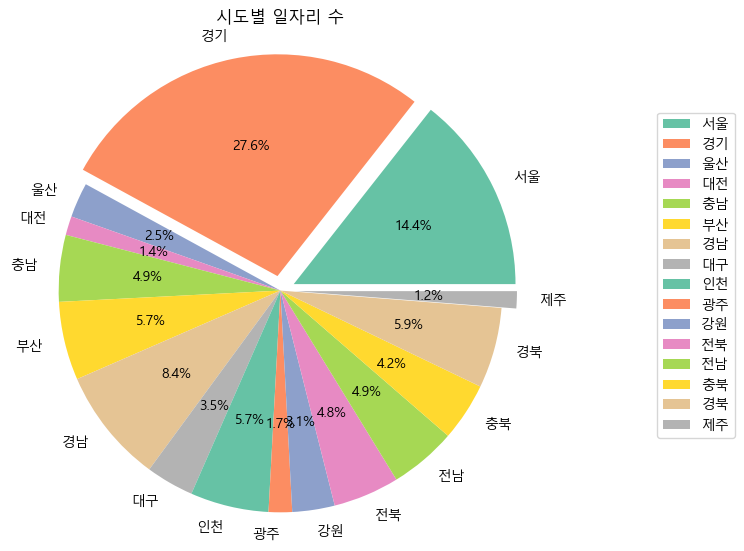

In [33]:


sidoCopy.sort_values('1인당평균거래금액', ascending=False, inplace=True)



list_explode = [0 for i in range(sidoCopy['일자리수'].size)]
list_explode[0] = 0.1
list_explode[1] = 0.1
list_explode[-1] = 0.1

colors = sns.color_palette("Set2")
plt.pie(sidoCopy['일자리수'],labels=sidoCopy['시도'] ,
        autopct="%.1f%%", colors = colors, explode = list_explode , radius=1.5)
plt.title('시도별 일자리 수', pad = 60)
plt.legend(bbox_to_anchor=(1.5, 1.0), loc="upper left")

plt.show()

# 시도별 평균 연봉

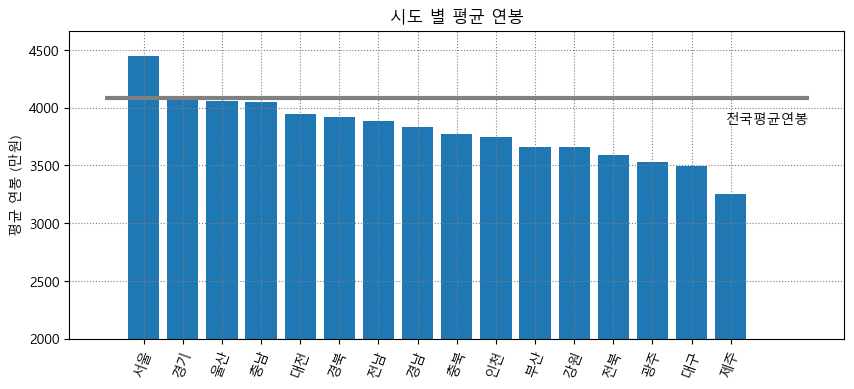

In [34]:
### 시도별 평균연봉

plt.figure(figsize=(10,4))

sidoCopy.sort_values('연봉(만원)', ascending=False, inplace=True)

plt.bar(sidoCopy['시도'], sidoCopy['연봉(만원)'])

plt.xticks(rotation=70) 
plt.title("시도 별 평균 연봉")
plt.ylabel("평균 연봉 (만원)")
plt.ylim(2000)
plt.yticks(range(2000,5000,500))
plt.hlines(totalYeonbong, -1, 17, color='gray', linestyle='solid', linewidth=3)
plt.text(17, (totalYeonbong - 190), '전국평균연봉', ha='right', va='center')

plt.grid(True, color = 'grey', linestyle=":")

plt.show()

# 지역별 일자리수 히트맵 >> 김성재 파일에 별도로 제작코드 있음

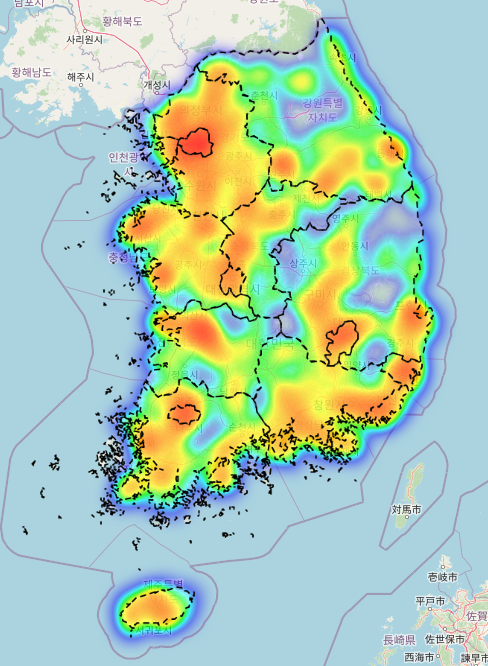

# 시도별 평균 거래금액

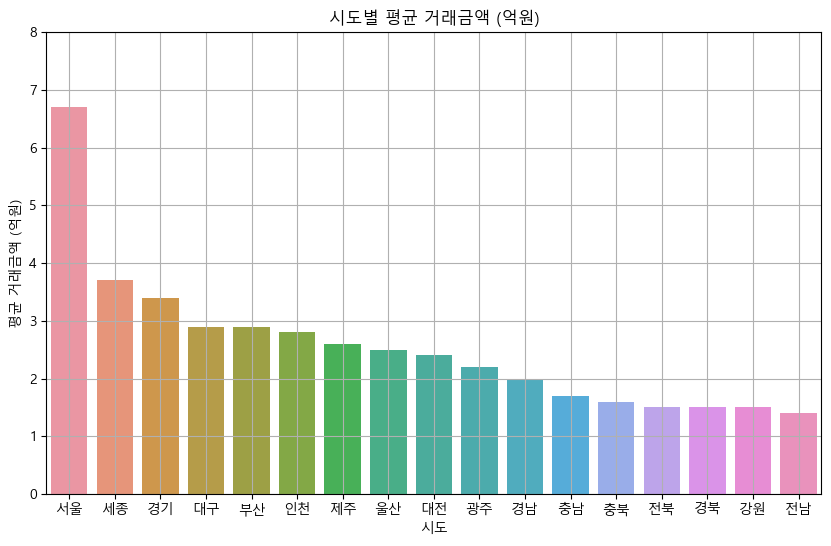

In [35]:
sido_mean_deal_cash = apart_rev3.groupby('시도',as_index=False).agg(시도별_평균_거래금액=('거래금액','mean'))

sido_mean_deal_cash['시도별_평균_거래금액'] = round((sido_mean_deal_cash['시도별_평균_거래금액']*10000)/100000000,1)

sido_mean_deal_cash = sido_mean_deal_cash.sort_values('시도별_평균_거래금액',ascending = False)

plt.figure(figsize = (10,6))

sns.barplot(data = sido_mean_deal_cash, x= '시도', y= '시도별_평균_거래금액')

# plt.xticks(rotation = 45)
plt.ylabel('평균 거래금액 (억원)')
plt. ylim(0,8)
plt.title('시도별 평균 거래금액 (억원)')
plt.grid()
plt.show()

# 시도별 평균 평당 거래금액

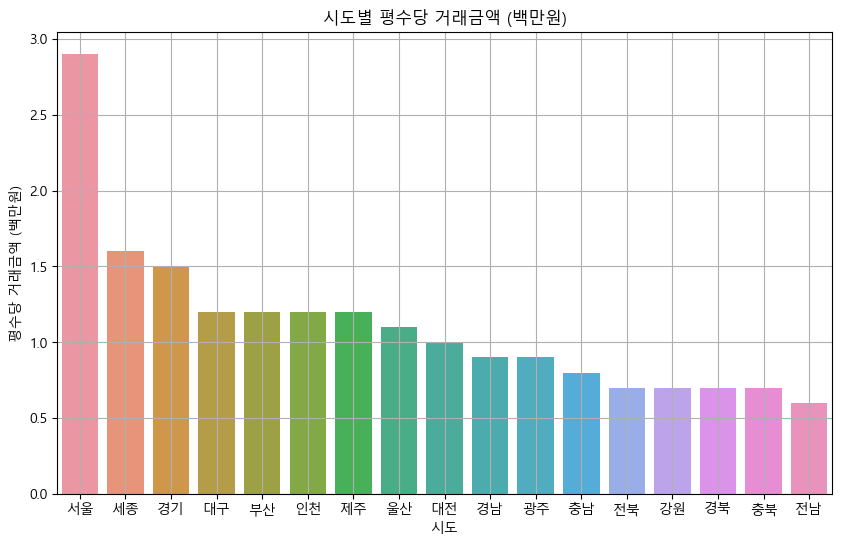

In [38]:
sido_pyung_deal_cash = apart_rev3.groupby('시도',as_index = False).agg(시도별_평수당_거래금액=('평수당거래금액','mean'))


sido_pyung_deal_cash['시도별_평수당_거래금액'] = round((sido_pyung_deal_cash['시도별_평수당_거래금액']*10000)/10000000,1)
sido_pyung_deal_cash_sort = sido_pyung_deal_cash.sort_values('시도별_평수당_거래금액',ascending=False)
plt.figure(figsize = (10,6))

sns.barplot(data = sido_pyung_deal_cash_sort, x= '시도', y= '시도별_평수당_거래금액')

# plt.xticks(rotation = 45)
plt.ylabel('평수당 거래금액 (백만원)')

plt.title('시도별 평수당 거래금액 (백만원)')
plt.grid()
plt.show()

# 연봉대비 거래금액

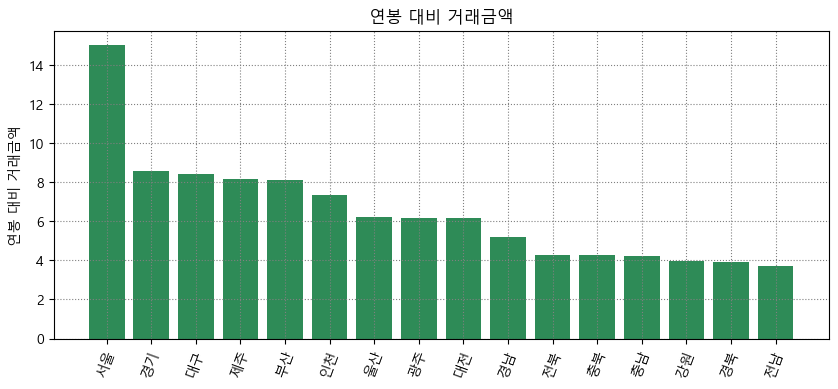

In [39]:
plt.figure(figsize=(10,4))

sidoCopy.sort_values('연봉대비거래금액', ascending=False, inplace=True)

plt.bar(sidoCopy['시도'], sidoCopy['연봉대비거래금액'], color='seagreen')

plt.xticks(rotation=70) 
plt.title("연봉 대비 거래금액")
plt.ylabel("연봉 대비 거래금액")

plt.grid(True, color = 'grey', linestyle=":")

plt.show()

# 서울시 평당 거래금액 히트맵 >> 김성재 파일에 코드 및 html파일 있음

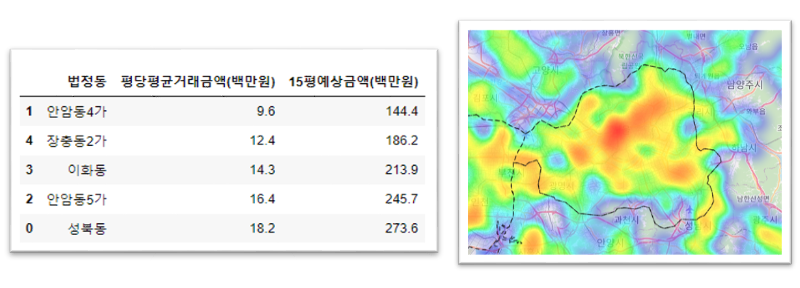

# 서울 하위 5개동 평당 가격 및 15평형 가격 , 2024년 가격

In [53]:
apartS = apart_rev3.query('시도 =="서울"')
apartS = apartS.query('거래년 == "2022"')
apartS = apartS.groupby('법정동',as_index = False).agg(평당평균거래금액 = ('평수당거래금액','mean')).sort_values('평당평균거래금액').head(5)
apartS['평당평균거래금액(백만원)'] = apartS['평당평균거래금액'].round(1)
apartS['2024 평당평균예상금액(백만원)'] = apartS['평당평균거래금액(백만원)']*1.116


,법정동,평당평균거래금액,평당평균거래금액(백만원),2024 평당평균예상금액(백만원)
170,안암동4가,962.466667,962.5,1074.1500
233,장충동2가,1425.300000,1425.3,1590.6348
221,이화동,1425.800000,1425.8,1591.1928
171,안암동5가,1637.700000,1637.7,1827.6732
136,성북동,1824.300000,1824.3,2035.9188


In [57]:
apartS['15평'] = apartS['평당평균거래금액(백만원)']*15

In [58]:
apartS

,법정동,평당평균거래금액,평당평균거래금액(백만원),2024 평당평균예상금액(백만원),15평
170,안암동4가,962.466667,962.5,1074.1500,14437.5
233,장충동2가,1425.300000,1425.3,1590.6348,21379.5
221,이화동,1425.800000,1425.8,1591.1928,21387.0
171,안암동5가,1637.700000,1637.7,1827.6732,24565.5
136,성북동,1824.300000,1824.3,2035.9188,27364.5


In [59]:
apartS = apartS.drop('2024 평당평균예상금액(백만원)',axis=1)
apartS

,법정동,평당평균거래금액,평당평균거래금액(백만원),15평
170,안암동4가,962.466667,962.5,14437.5
233,장충동2가,1425.300000,1425.3,21379.5
221,이화동,1425.800000,1425.8,21387.0
171,안암동5가,1637.700000,1637.7,24565.5
136,성북동,1824.300000,1824.3,27364.5


In [60]:
apartS['2024년 15평 예상금액'] = apartS['15평'] * 1.16

In [61]:
apartS['평당평균거래금액'] = round(apartS['평당평균거래금액']*10000/1000000,1)
apartS

,법정동,평당평균거래금액,평당평균거래금액(백만원),15평,2024년 15평 예상금액
170,안암동4가,9.6,962.5,14437.5,16747.50
233,장충동2가,14.3,1425.3,21379.5,24800.22
221,이화동,14.3,1425.8,21387.0,24808.92
171,안암동5가,16.4,1637.7,24565.5,28495.98
136,성북동,18.2,1824.3,27364.5,31742.82


In [62]:
apartS  = apartS.drop('평당평균거래금액(백만원)',axis = 1)
apartS['2024년 15평 예상금액(억원)'] = round(apartS['2024년 15평 예상금액']*10000/100000000,1)
apartS = apartS.drop('2024년 15평 예상금액',axis = 1)

,법정동,평당평균거래금액,15평,2024년 15평 예상금액(억원)
170,안암동4가,9.6,14437.5,1.7
233,장충동2가,14.3,21379.5,2.5
221,이화동,14.3,21387.0,2.5
171,안암동5가,16.4,24565.5,2.8
136,성북동,18.2,27364.5,3.2


In [64]:
apartS['15평(억원)'] = round(apartS['15평']*10000/100000000,1)

In [65]:
apartS

,법정동,평당평균거래금액,15평,2024년 15평 예상금액(억원),15평(억원)
170,안암동4가,9.6,14437.5,1.7,1.4
233,장충동2가,14.3,21379.5,2.5,2.1
221,이화동,14.3,21387.0,2.5,2.1
171,안암동5가,16.4,24565.5,2.8,2.5
136,성북동,18.2,27364.5,3.2,2.7


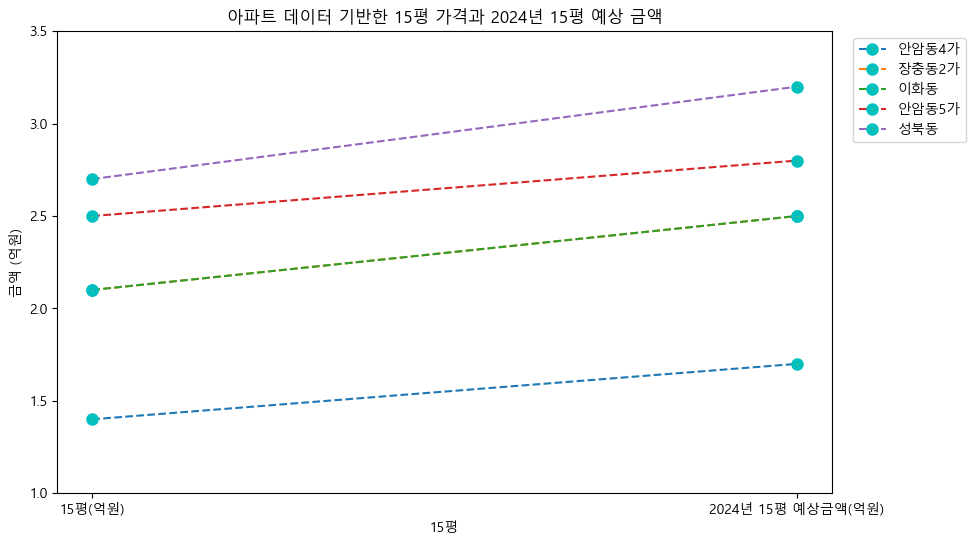

In [66]:


plt.figure(figsize=(10, 6))

for i, row in apartS.iterrows():
    plt.plot(['15평(억원)', '2024년 15평 예상금액(억원)'], [row['15평(억원)'], row['2024년 15평 예상금액(억원)']], label=row['법정동'], marker = 'o', ms = 5, mec = "c", mew = 4, mfc = 'y',ls= '--')

plt.xlabel('15평')
plt.ylabel('금액 (억원)')
plt.ylim(1,3.5)
plt.title('아파트 데이터 기반한 15평 가격과 2024년 15평 예상 금액')
plt.legend(bbox_to_anchor=(1.1, 1.0),loc = 'upper center')

plt.show()

# 서울시 년도별 평당 거래금액

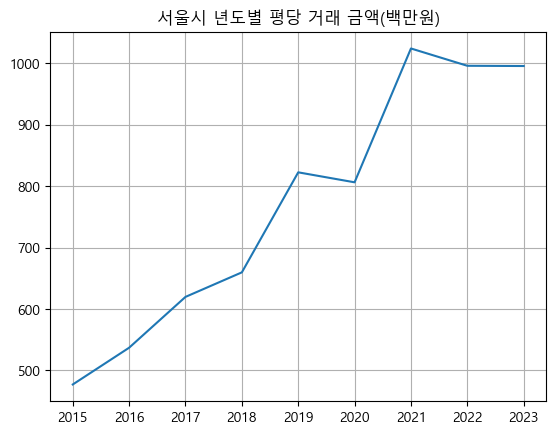

In [55]:
plt.title('서울시 년도별 평당 거래 금액(백만원)')
apartSeoul = apart_rev3.query('시도 == "서울"')
apartSeoul = apartSeoul.groupby('거래년',as_index = False).agg(평당거래금액  = ('거래금액','mean'))
apartSeoul['평당거래금액'] = apartSeoul['평당거래금액'].round(1)
apartSeoul['평당거래금액(백만원)'] = apartSeoul['평당거래금액']/100
apartSeoul = apartSeoul.rename(columns = {'거래년':'서울시 년도별'})
ylabel = '평당거래금액(백만원)'
xlabe = '서울시 년도별'
plt.plot(apartSeoul['서울시 년도별'],apartSeoul['평당거래금액(백만원)'])
plt.grid()


# 평균거래금액이 가장 비싼아파트는?

In [67]:
mean_apart = apart_rev3.groupby(['아파트','시도','지역이름','법정동'],as_index = False).agg(평균거래금액=('거래금액','mean')).sort_values('평균거래금액',ascending = False)

mean_apart_top15 = mean_apart.head(15)

apart_deal_count = apart_rev2.groupby('아파트',as_index=False).agg(거래건수=('아파트','count'))

mean_apart_top15_count = pd.merge(mean_apart_top15,apart_deal_count, how='left',on='아파트')
mean_apart_top15_count['아파트_시도_법정동'] = mean_apart_top15_count['아파트']+'_'+mean_apart_top15_count['시도']+'_'+mean_apart_top15_count['법정동']
mean_apart_top15_count['평균거래금액'] = (mean_apart_top15_count['평균거래금액']*10000)/100000000

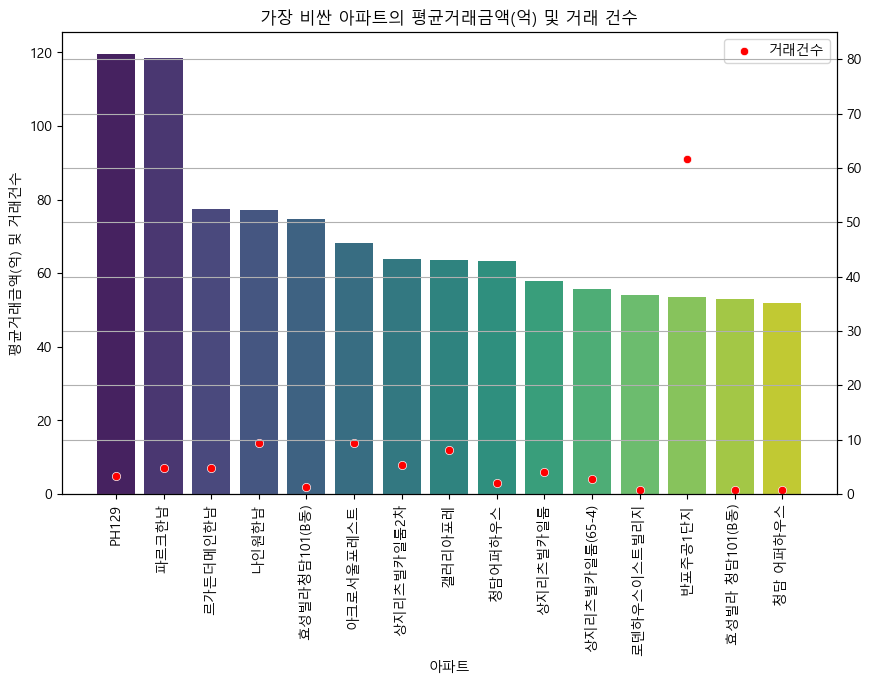

In [68]:


plt.figure(figsize=(10, 6))

sns.barplot(x='아파트', y='평균거래금액', data= mean_apart_top15_count, palette='viridis')

sns.scatterplot(data = mean_apart_top15_count, x= '아파트', y= '거래건수',color = 'red',label='거래건수')

plt.title('가장 비싼 아파트의 평균거래금액(억) 및 거래 건수')

plt.xlabel('아파트')

plt.ylabel('평균거래금액(억) 및 거래건수')

plt.xticks(rotation = 90)

plt.twinx()

plt.ylim(0, 85)

plt.grid()

plt.show()


# # 평균거래금액(억)에 대한 barplot
# ax1 = plt.subplot(121)
# sns.barplot(x='평균거래금액', y='아파트', data=mean_apart_top15_count, palette='viridis', ax=ax1)
# ax1.set(title='아파트별 평균거래금액(억)', xlabel='평균거래금액(억 원)', ylabel='아파트')

# # 거래건수에 대한 scatterplot
# ax2 = plt.subplot(122)
# sns.scatterplot(x='거래건수', y='아파트', data=mean_apart_top15_count, color='orange', ax=ax2)
# ax2.set(title='아파트별 거래건수', xlabel='거래건수', ylabel='아파트')

# plt.tight_layout()
# plt.show()